In [1]:
# sklearn has a lot of warnings.... suppress them all
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import argparse
import copy
import glob
import json
import math
import os
import pickle
import re
import scipy
import sys
import random
import torch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

from itertools import combinations
from numpy.random import RandomState

from collections import defaultdict
from os.path import exists
from scipy import linalg
from scipy.io import loadmat
from scipy.special import logsumexp
from scipy.stats import multivariate_normal
from scipy.spatial import distance
from sklearn import mixture
from sklearn.covariance import EmpiricalCovariance
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sys import getsizeof
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200


from sklearn.metrics import roc_auc_score
from scipy import stats
from scipy.stats import norm

sys.path.append("/om2/user/bjmedina/memory/utils/")

#from util_plotting import convertModelResponsesToDataFrame

sys.path.append('/om2/user/bjmedina/')


In [2]:
prng = RandomState()
transform = False
z_score = False

noise_std_dev = 1
stim_filenames = "/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_p1/filenames.json"
# Opening JSON file
f = open(stim_filenames)
stim_files = json.load(f)

In [3]:
representation = np.load("/om2/user/bjmedina/BOLIVIA2024/assets/textures/texture_statistics_1707.npy")
data_transform = np.load("/om2/user/bjmedina/BOLIVIA2024/assets/textures/texture_1707_transform.npy")

clip_to_idx = {}

for j in range(len(stim_files)):
    clip_to_idx[stim_files[j]['filename']] = int(stim_files[j]['filename'].split("_")[-1].split(".")[0])


mean = np.mean(representation, axis=0)
std_dev = np.std(representation, axis=0)

# Z-score each feature
representation_z = (representation - mean) / std_dev

if transform:
    representation = representation @ data_transform
    name = "transformed data"
else:
    name = "untransformed data"

print("Z-scored data:\n", representation_z)


Z-scored data:
 [[ 1.2513745   0.6539005   1.8810276  ...  0.5635866   0.8526896
   0.63836557]
 [ 0.03793416  0.6461666  -0.29168588 ... -0.385245   -0.42748404
  -0.4192406 ]
 [-0.26768187 -0.4150972  -0.16212575 ... -0.36884314 -0.41812557
  -0.41174725]
 ...
 [-2.1413774  -2.616238   -2.159279   ... -0.32131344 -0.34468707
  -0.33954817]
 [-0.3852193  -0.00364514 -1.8830171  ... -0.04187845 -0.19160585
  -0.29845077]
 [-0.11905494  0.12469096 -0.4980301  ... -0.3940847  -0.43352574
  -0.42240104]]


In [4]:
eps = prng.normal(loc=0.0, scale=0, size=representation.shape)
eps[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [5]:
representation.shape

(181, 1707)

In [6]:
# Compute feature standard deviations
feature_std_dev = np.std(representation, axis=0)

# Avoid division by zero
feature_std_dev[feature_std_dev == 0] = 1

# Normalize representation
noise_std_dev_scaled = noise_std_dev * feature_std_dev


In [24]:
feature_std_dev.shape

(1707,)

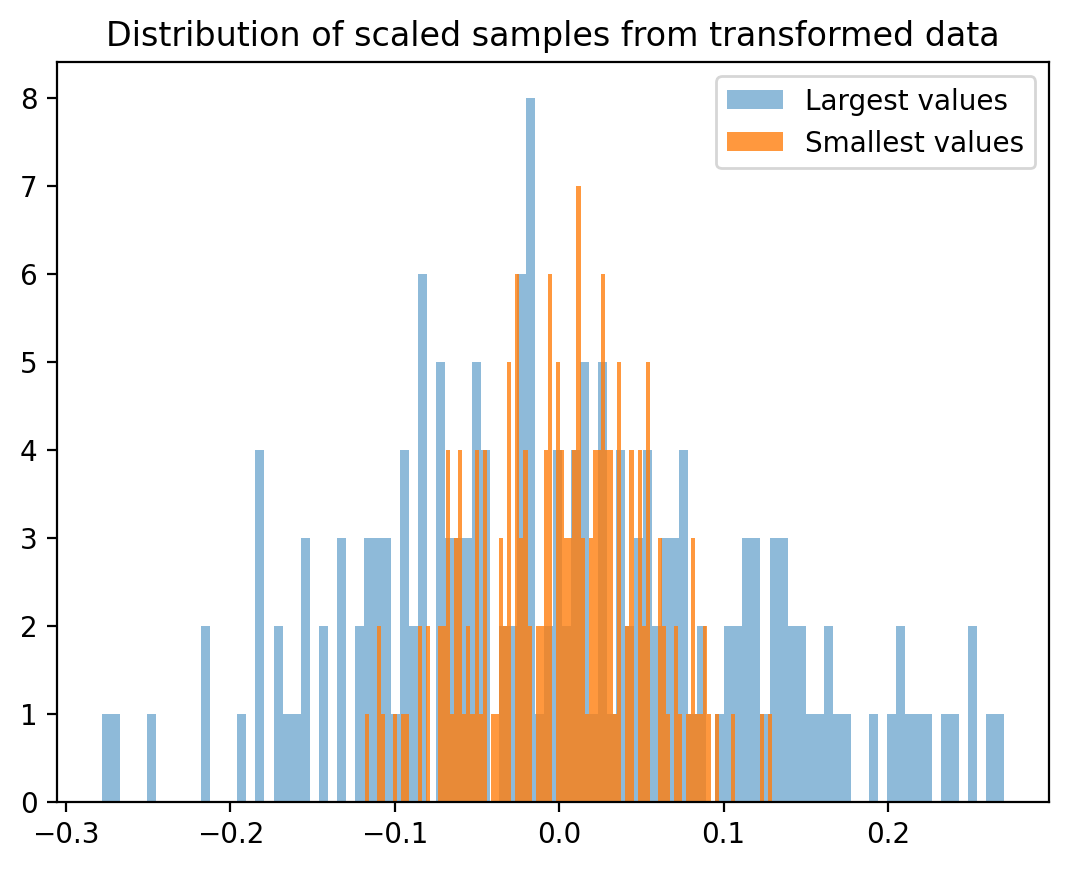

In [25]:
eps = prng.normal(loc=0.0, scale=noise_std_dev_scaled, size=representation.shape)
max_idx, min_idx = np.argmax(feature_std_dev), np.argmin(feature_std_dev)
plt.title(f"Distribution of scaled samples from {name}")
plt.hist(eps[:, max_idx], label="Largest values", bins=100, alpha=0.5)
plt.hist(eps[:, min_idx], label="Smallest values", bins=100, alpha=0.8)
plt.legend()

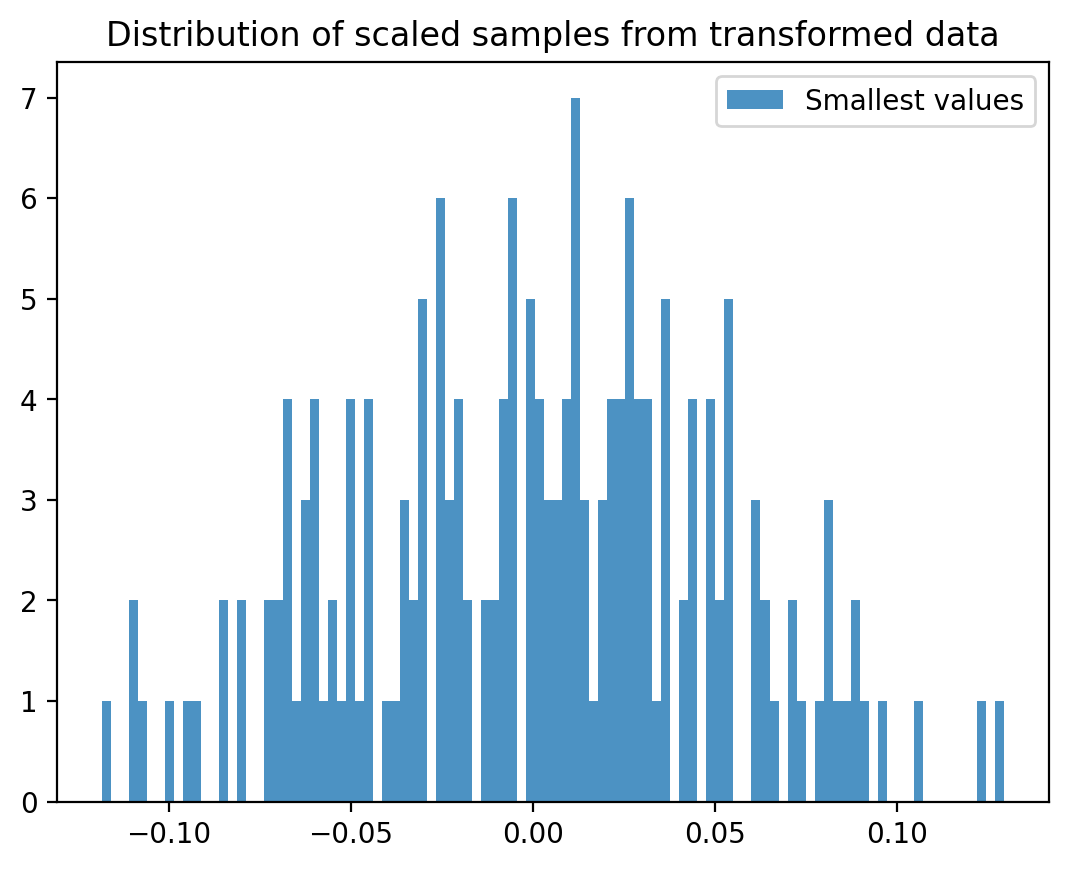

In [26]:
plt.title(f"Distribution of scaled samples from {name}")

plt.hist(eps[:, min_idx], label="Smallest values", bins=100, alpha=0.8)
plt.legend()

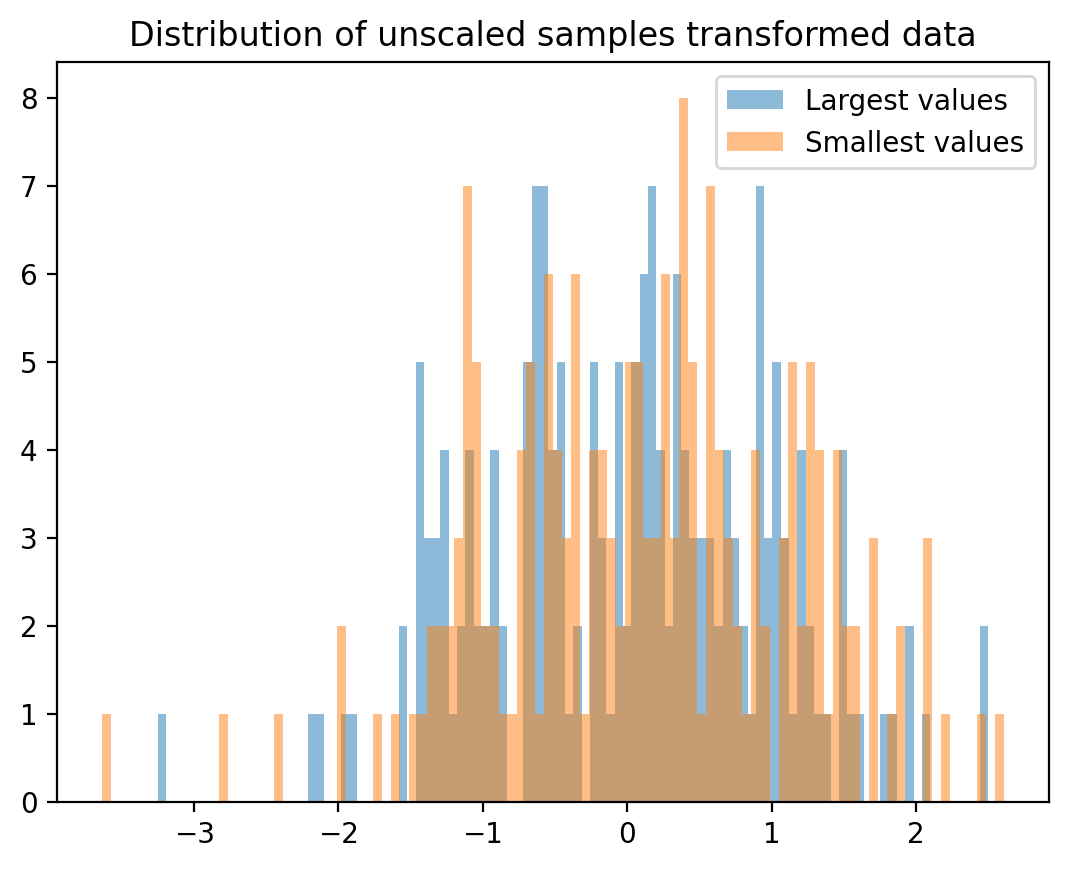

In [27]:
eps = prng.normal(loc=0.0, scale=noise_std_dev, size=representation.shape)
plt.title(f"Distribution of unscaled samples {name}")
plt.hist(eps[:, max_idx], label="Largest values", bins=100, alpha=0.5)
plt.hist(eps[:, min_idx], label="Smallest values", bins=100, alpha=0.5)
plt.legend()

Text(0.5, 1.0, 'std of features for transformed data')

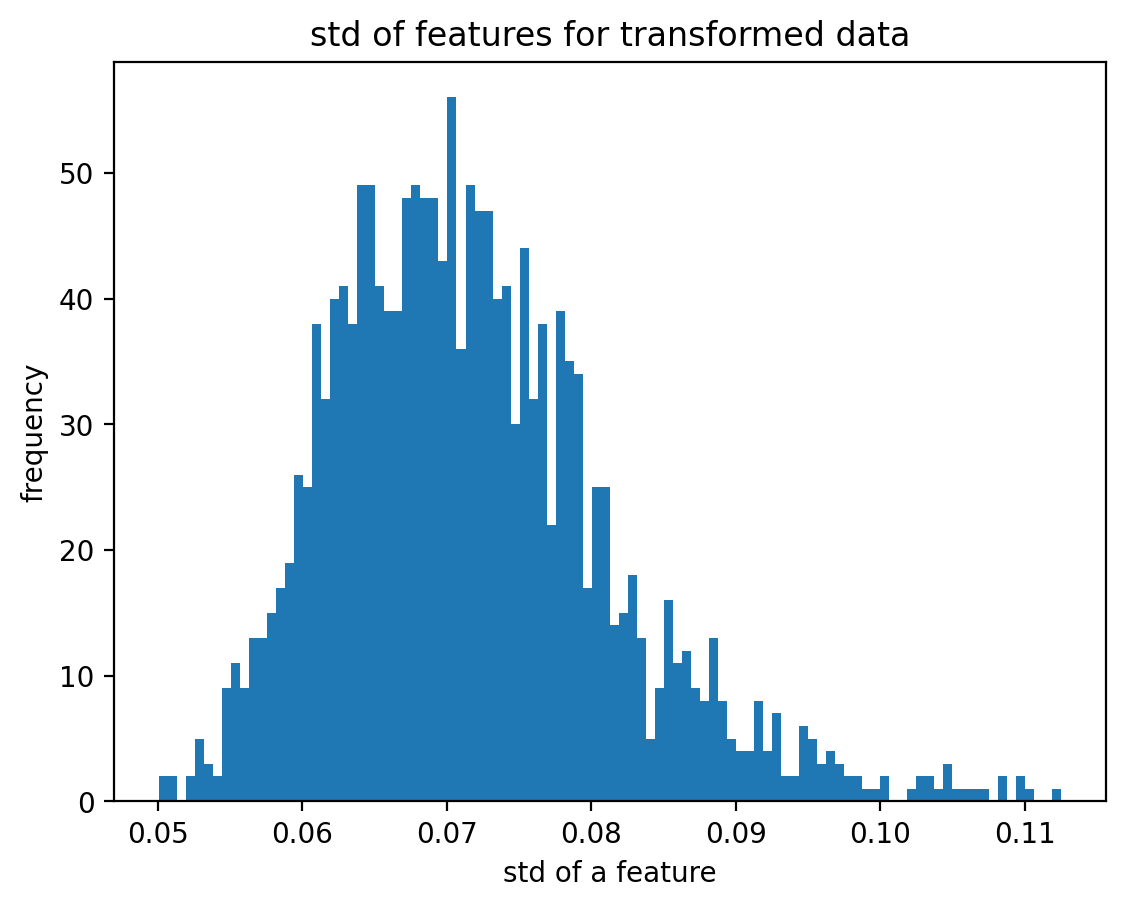

In [28]:
plt.hist(feature_std_dev, bins=100)
plt.xlabel("std of a feature")
plt.ylabel("frequency")
plt.title(f"std of features for {name}")

In [29]:
# Compute feature standard deviations
feature_std_dev = np.std(representation_z, axis=0)

# Avoid division by zero
feature_std_dev[feature_std_dev == 0] = 1

# Normalize representation
noise_std_dev_scaled = noise_std_dev * feature_std_dev


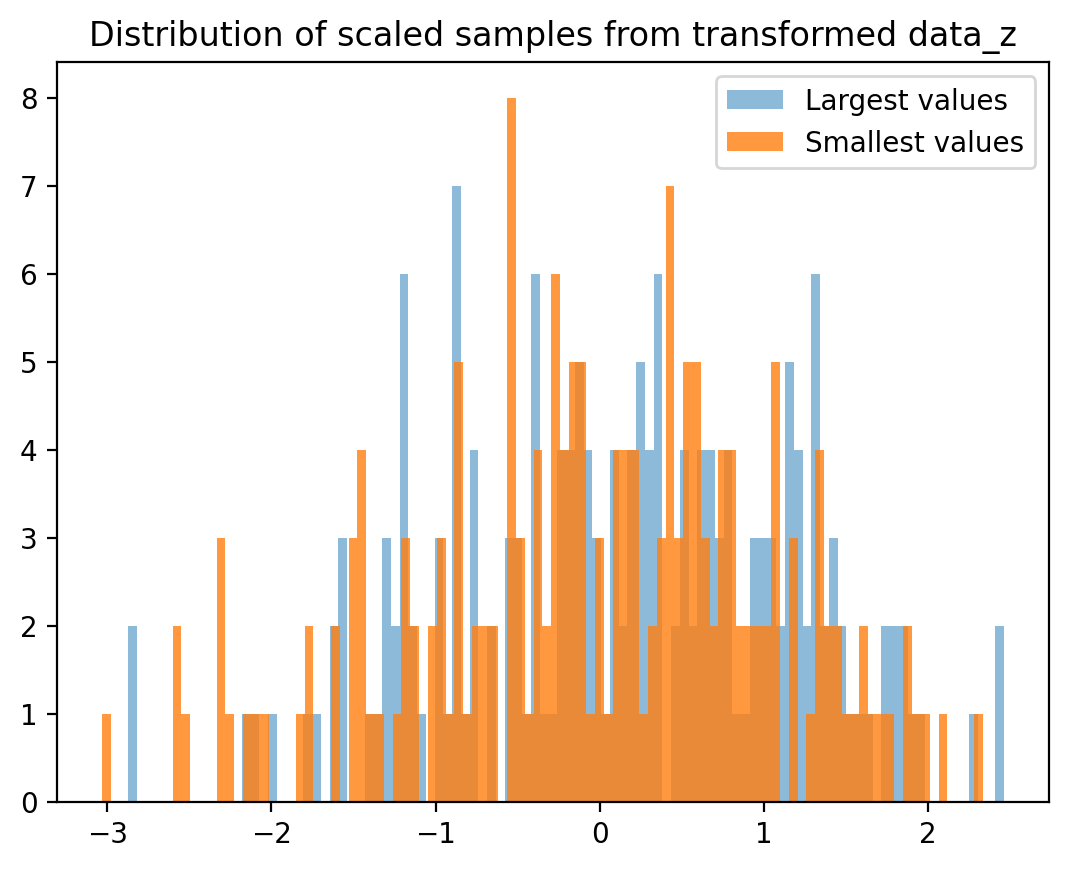

In [30]:
eps = prng.normal(loc=0.0, scale=noise_std_dev_scaled, size=representation.shape)
max_idx, min_idx = np.argmax(feature_std_dev), np.argmin(feature_std_dev)
plt.title(f"Distribution of scaled samples from {name}_z")
plt.hist(eps[:, max_idx], label="Largest values", bins=100, alpha=0.5)
plt.hist(eps[:, min_idx], label="Smallest values", bins=100, alpha=0.8)
plt.legend()

Text(0.5, 1.0, 'std of features for transformed data')

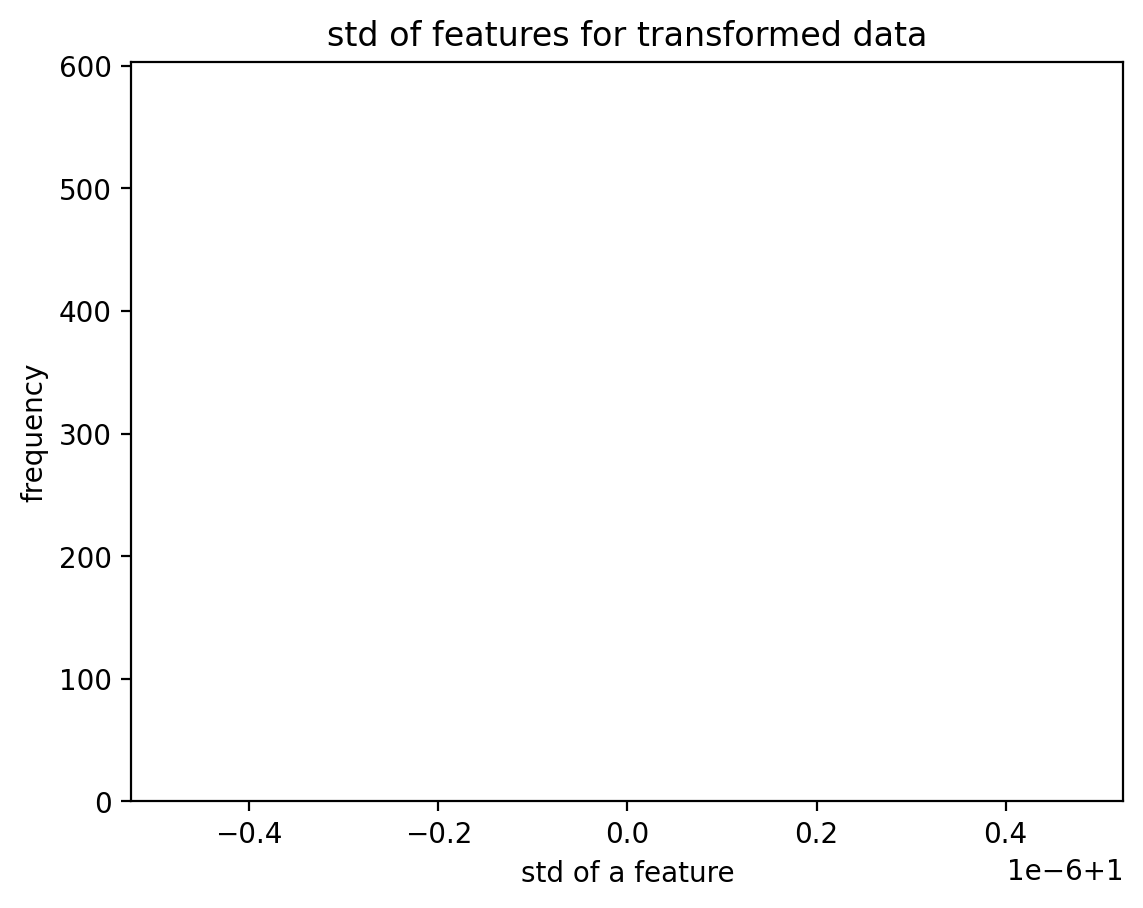

In [31]:
plt.hist(feature_std_dev, bins=100)
plt.xlabel("std of a feature")
plt.ylabel("frequency")
plt.title(f"std of features for {name}")

In [32]:
representation = np.load("/om2/user/bjmedina/BOLIVIA2024/assets/textures/texture_statistics_1707.npy")
data_transform = np.load("/om2/user/bjmedina/BOLIVIA2024/assets/textures/texture_1707_transform.npy")

clip_to_idx = {}

for j in range(len(stim_files)):
    clip_to_idx[stim_files[j]['filename']] = int(stim_files[j]['filename'].split("_")[-1].split(".")[0])

if transform:

    mean = np.mean(representation, axis=0)
    std_dev = np.std(representation, axis=0)
    
    # Z-score each feature
    representation_z = (representation - mean) / std_dev
    representation_z = representation_z @ data_transform

    print("Z-scored data:\n", representation_z)
    name = "transformed data"
else:
    
    mean = np.mean(representation, axis=0)
    std_dev = np.std(representation, axis=0)
    
    # Z-score each feature
    representation_z = (representation - mean) / std_dev
    print("Z-scored data:\n", representation_z)
    name = "untransformed data"




Z-scored data:
 [[-0.1879154  -0.14294696  2.2233107  ... -0.34773573  1.9733397
   0.5758679 ]
 [ 0.17993337 -0.13417704 -0.24028915 ...  0.5957611   0.6715404
  -0.20336322]
 [-0.15848765 -0.4749372  -0.8597113  ...  0.28420645 -0.09668563
  -0.15401612]
 ...
 [ 0.31411585 -0.02423796 -0.44276667 ...  0.8186966   0.2577912
  -0.7777462 ]
 [-0.48832038 -0.7760621  -0.38403234 ...  0.47202462  0.1407182
  -0.71462315]
 [-0.9330728  -0.0893217  -0.2307975  ...  0.7543421  -0.37006968
  -0.0476487 ]]


In [33]:
# Compute feature standard deviations
feature_std_dev = np.std(representation_z, axis=0)

# Avoid division by zero
feature_std_dev[feature_std_dev == 0] = 1

# Normalize representation
noise_std_dev_scaled = noise_std_dev * feature_std_dev


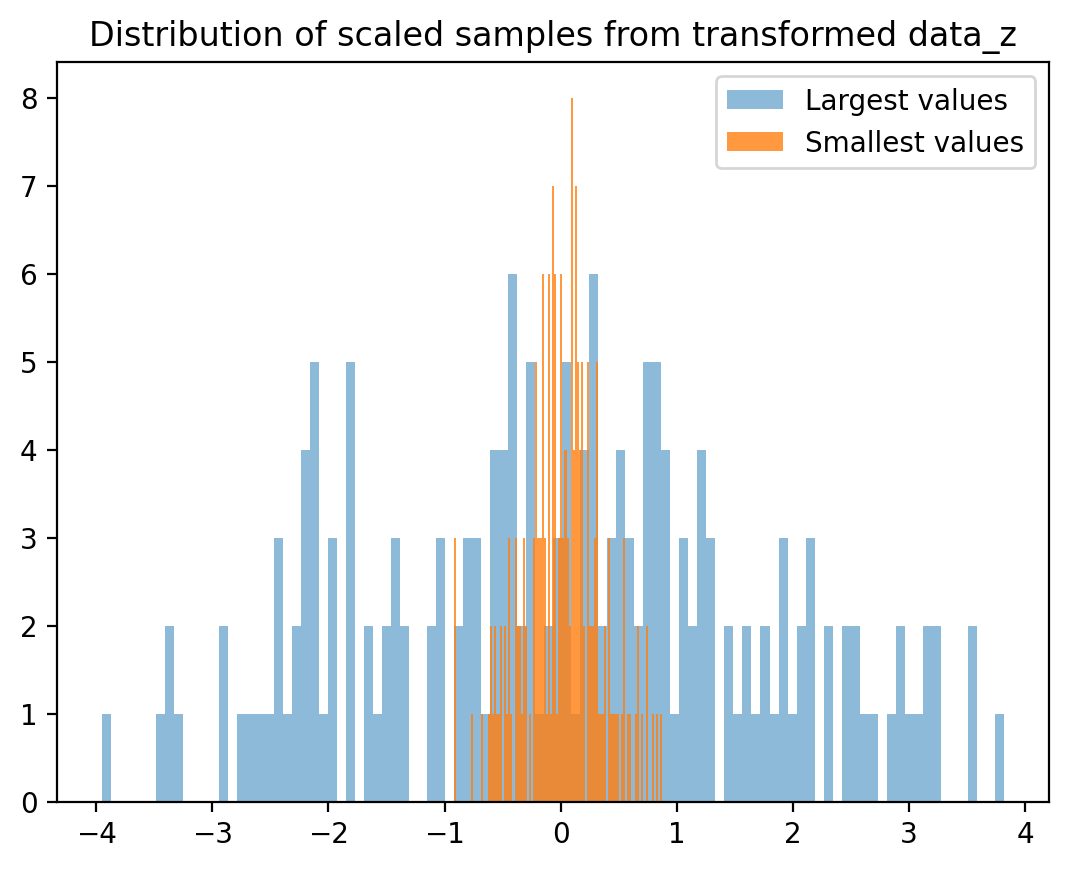

In [34]:
eps = prng.normal(loc=0.0, scale=noise_std_dev_scaled, size=representation.shape)
max_idx, min_idx = np.argmax(feature_std_dev), np.argmin(feature_std_dev)
plt.title(f"Distribution of scaled samples from {name}_z")
plt.hist(eps[:, max_idx], label="Largest values", bins=100, alpha=0.5)
plt.hist(eps[:, min_idx], label="Smallest values", bins=100, alpha=0.8)
plt.legend()

Text(0.5, 1.0, 'std of features for transformed data')

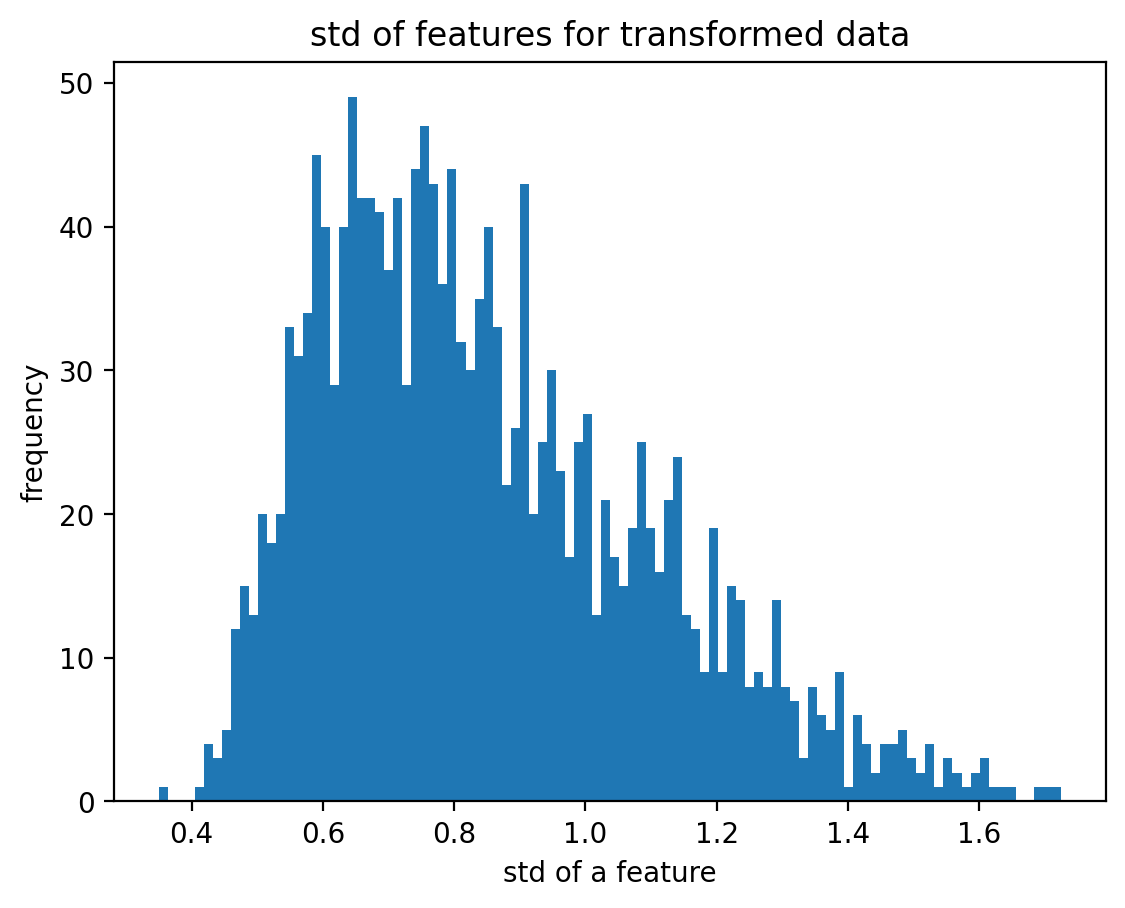

In [35]:
plt.hist(feature_std_dev, bins=100)
plt.xlabel("std of a feature")
plt.ylabel("frequency")
plt.title(f"std of features for {name}")